# M3 - Strength criteria

**Tutoring track, 057922 Nuclear Design and Technology** · Politecnico di Milano

Author: Giovanni Zullo

Run the cells in order, or **Runtime > Run all**.

---

## Contents

1. Yield criteria
2. Why ASME III uses Tresca
3. Brittle materials: the Galileo-Rankine criterion
4. Exercises


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.figsize': (6.5, 6.5), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})

# A neutral steel.
E, nu = 200e9, 0.30                      # Pa, -
print(f'E = {E/1e9:.1f} GPa,  nu = {nu}')

E = 200.0 GPa,  nu = 0.3


---
## 1. Yield criteria

A strength criterion reduces the stress tensor to one scalar, the **failure index**, chosen
so that two states with the same value are equally dangerous, and declares failure when it
reaches the value it has in the tensile test at yield. Written in stress units it is the
**equivalent** (or **comparison**) **stress**, and that is what a verification compares
with the allowable. Hydrostatic stress alone does not make a metal yield, so for a metal
the index must depend on the **deviator** only. The two classical
choices:

**Tresca** (Guest-Tresca-Saint Venant) - yielding begins when the maximum shear reaches a critical value:
$$\sigma_{\text{Tr}} = \sigma_1 - \sigma_3 = 2\tau_{\max} \;\le\; \sigma_Y .$$

**von Mises** (Huber-Hencky-von Mises) - yielding begins when the distortion energy reaches a critical value:
$$\sigma_{\text{VM}} = \sqrt{3J_2}
= \sqrt{\tfrac12\big[(\sigma_1-\sigma_2)^2+(\sigma_2-\sigma_3)^2+(\sigma_3-\sigma_1)^2\big]}
\;\le\; \sigma_Y .$$

In the space of principal stresses both are prisms along the hydrostatic axis - von
Mises a cylinder, Tresca a hexagonal prism inscribed in it. They **coincide** in uniaxial
tension (both calibrated there) and are **furthest apart in pure shear**, where the ratio of
the two reaches $2/\sqrt3$. For every stress state

$$1 \;\le\; \frac{\sigma_{\text{Tr}}}{\sigma_{\text{VM}}} \;\le\; \frac{2}{\sqrt3}
\approx 1.1547 .$$

**Tresca is therefore always the more conservative of the two**, by at most 15%.

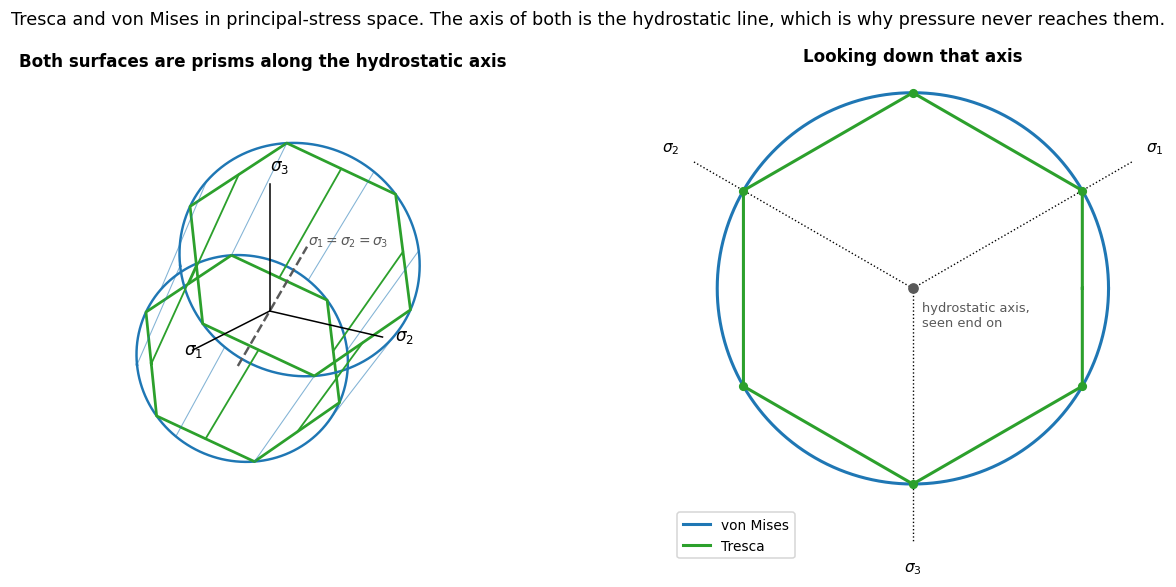

*The two criteria as surfaces. Left: both are **prisms**, open at both ends along $\sigma_1=\sigma_2=\sigma_3$, which is the whole content of "pressure does not cause yielding" - you can slide along that axis forever without reaching either surface. Right: looking down it, Tresca is a hexagon inscribed in the von Mises circle, touching at six points. The dotted lines are the three uniaxial directions, and they run through those six points: that is why the two criteria agree in uniaxial tension, where both are calibrated. Drawn by `figures/make_figures.py`.*


In [2]:
def tresca(s): 
    w = np.sort(np.linalg.eigvalsh(s))
    return w[-1] - w[0]

def von_mises(s):
    d = s - np.trace(s)/3*np.eye(3)
    return np.sqrt(1.5*np.sum(d*d))

rng = np.random.default_rng(1)
ratios = []
for _ in range(200000):
    a = rng.standard_normal((3, 3))
    s = (a + a.T)/2
    vm = von_mises(s)
    if vm > 1e-9:
        ratios.append(tresca(s)/vm)
ratios = np.array(ratios)
print(f'over {len(ratios)} random stress states:')
print(f'   min  Tresca/vonMises = {ratios.min():.6f}   (theory: 1)')
print(f'   max  Tresca/vonMises = {ratios.max():.6f}   (theory: 2/sqrt(3) = {2/np.sqrt(3):.6f})')
print(f'   mean                 = {ratios.mean():.4f}')

# the two extreme cases, exactly
uni = np.diag([100.0, 0.0, 0.0])
shear = np.array([[0.0, 100.0, 0.0], [100.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
print(f'\nuniaxial tension: Tresca = {tresca(uni):.2f}, vonMises = {von_mises(uni):.2f},'
      f' ratio = {tresca(uni)/von_mises(uni):.4f}')
print(f'pure shear      : Tresca = {tresca(shear):.2f}, vonMises = {von_mises(shear):.2f},'
      f' ratio = {tresca(shear)/von_mises(shear):.4f}')

over 200000 random stress states:
   min  Tresca/vonMises = 1.000497   (theory: 1)
   max  Tresca/vonMises = 1.154701   (theory: 2/sqrt(3) = 1.154701)
   mean                 = 1.1249

uniaxial tension: Tresca = 100.00, vonMises = 100.00, ratio = 1.0000
pure shear      : Tresca = 200.00, vonMises = 173.21, ratio = 1.1547


> **A trap in print: Tresca in plane stress.** Ye (*Structural and Stress Analysis*,
> Eq. 9.2) writes Tresca for a two-dimensional state as
> $\sigma_{eq} = \sqrt{(\sigma_x-\sigma_y)^2+4\tau_{xy}^2} = \sigma_1-\sigma_2$, the in-plane
> shear only, and forgets that $\sigma_3 = 0$ is a principal stress too. For the 2:1 state
> of a thin cylinder under pressure, $(\sigma_1, \sigma_2) = (200, 100)$ MPa, that gives
> 100 MPa; the right value is $\sigma_1 - \sigma_3 = 200$ MPa, twice as much. In plane
> stress Tresca is $\max(|\sigma_1-\sigma_2|,\,|\sigma_1|,\,|\sigma_2|)$, and the in-plane
> formula is right only when $\sigma_1$ and $\sigma_2$ have opposite signs.


### Beltrami, and why von Mises keeps only part of the energy

Von Mises was not the first energy criterion. **Beltrami** took the *whole* elastic energy
stored per unit volume as the failure index, calibrated on the tensile test:

$$\sigma_{\text{B}} = \sqrt{\sigma_1^2+\sigma_2^2+\sigma_3^2
- 2\nu\,(\sigma_1\sigma_2+\sigma_2\sigma_3+\sigma_3\sigma_1)} \;\le\; \sigma_Y .$$

The whole energy includes the part that only changes the volume, and that is where the
criterion goes wrong for a metal. Under hydrostatic pressure it predicts yielding, at
$p \approx 0.91\,\sigma_Y$ for $\nu = 0.3$, which a metal does not do. In pure shear it lets
the stress reach $\tau = \sigma_Y/\sqrt{2(1+\nu)} \approx 0.62\,\sigma_Y$, above both von
Mises and Tresca, so there it is on the unsafe side. Drop the volumetric part, keep only
the energy of distortion, and what is left is von Mises.


In [3]:
def beltrami(s, nu=nu):
    w = np.linalg.eigvalsh(s)
    return np.sqrt(np.sum(w**2) - 2*nu*(w[0]*w[1] + w[1]*w[2] + w[2]*w[0]))

pure_shear = np.array([[0., 1., 0.], [1., 0., 0.], [0., 0., 0.]])   # unit shear
pressure = -np.eye(3)                                              # unit hydrostatic pressure
print(f"{'criterion':>10} {'tau at yield / sigma_Y':>24} {'pressure at yield / sigma_Y':>29}")
for name, f in (('Tresca', tresca), ('von Mises', von_mises), ('Beltrami', beltrami)):
    p_y = f'{1/f(pressure):.3f}' if f(pressure) > 1e-12 else 'never'
    print(f'{name:>10} {1/f(pure_shear):24.3f} {p_y:>29}')
print('\nOnly Beltrami yields under pressure, and only Beltrami lets pure shear go past 0.577.')
assert np.isclose(1/beltrami(pure_shear), 1/np.sqrt(2*(1 + nu)))


 criterion   tau at yield / sigma_Y   pressure at yield / sigma_Y
    Tresca                    0.500                         never
 von Mises                    0.577                         never
  Beltrami                    0.620                         0.913

Only Beltrami yields under pressure, and only Beltrami lets pure shear go past 0.577.


### Roš-Eichinger: the same surface, read on the octahedral plane

Take the plane whose normal makes equal angles with the three principal directions,
$\mathbf n = (1,1,1)/\sqrt3$ in the principal frame. Flipping the signs gives eight
such normals, $(\pm1,\pm1,\pm1)/\sqrt3$, and their eight planes enclose an octahedron,
hence the name. All eight carry the same normal stress and the same amount of shear.
The normal stress is the mean stress,
$\sigma_{\text{oct}} = \tfrac13(\sigma_1+\sigma_2+\sigma_3)$, which only changes the size of
the octahedron; the shear,

$$\tau_{\text{oct}} = \tfrac13\sqrt{(\sigma_1-\sigma_2)^2+(\sigma_2-\sigma_3)^2+(\sigma_3-\sigma_1)^2}
= \frac{\sqrt2}{3}\,\sigma_{\text{VM}},$$

only changes its shape. **Roš and Eichinger** took $\tau_{\text{oct}}$ as the failure index.
In the tensile test at yield it is $(\sqrt2/3)\,\sigma_Y \approx 0.471\,\sigma_Y$, so the
criterion is $\tau_{\text{oct}} \le 0.471\,\sigma_Y$, which multiplied out is von Mises
exactly. The two differ in what they claim to measure: von
Mises an elastic energy, which only means something while the material is elastic;
Roš-Eichinger a stress, which still means something once the material yields and hardens.


In [4]:
# The octahedral shear computed as a traction, not from the formula: rotate a random
# stress state to its principal frame, cut it with n = (1,1,1)/sqrt(3), and split the
# traction into its normal and shear parts.
rng_oct = np.random.default_rng(3)
a = rng_oct.standard_normal((3, 3)); s = 100*(a + a.T)
w, V = np.linalg.eigh(s)
n = V @ np.ones(3)/np.sqrt(3)                # the octahedral normal, in the original frame
t = s @ n
sig_oct = t @ n
tau_oct = np.sqrt(t @ t - sig_oct**2)
print(f'normal stress on the octahedral plane = {sig_oct:8.2f} MPa   mean stress = {np.trace(s)/3:8.2f} MPa')
print(f'shear  stress on the octahedral plane = {tau_oct:8.2f} MPa   (sqrt(2)/3) sigma_VM = {np.sqrt(2)/3*von_mises(s):8.2f} MPa')
print(f'at yield in the tensile test: tau_oct / sigma_Y = {np.sqrt(2)/3:.4f}')
assert np.isclose(sig_oct, np.trace(s)/3) and np.isclose(tau_oct, np.sqrt(2)/3*von_mises(s))


normal stress on the octahedral plane =    48.20 MPa   mean stress =    48.20 MPa
shear  stress on the octahedral plane =   386.53 MPa   (sqrt(2)/3) sigma_VM =   386.53 MPa
at yield in the tensile test: tau_oct / sigma_Y = 0.4714


### What the experiments say

None of these criteria is derived: each is a hypothesis about which scalar governs
failure, and only tests decide between them. Two results do.

- **Pressure.** Bridgman's tensile tests in a pressure chamber, at up to 25 000
  atmospheres, left the yield stress practically unchanged (Corradi Dell'Acqua §3.3.3).
  Any criterion that sees the hydrostatic part, Beltrami included, is ruled out for metals.
- **Torsion.** In pure shear many ductile metals yield about 15 % above Tresca's
  $\sigma_Y/2$, close to von Mises' $0.577\,\sigma_Y$ (Boresi §4.4). Tresca is
  conservative, von Mises closer.


---
## 2. Why ASME III uses Tresca

Section III of the Boiler and Pressure Vessel Code states, in NB-3212, that the failure
theory adopted is **maximum shear stress** - Tresca. Consequently everything in the code
is written in terms of **stress intensity**

$$S = \sigma_1 - \sigma_3 = 2\tau_{\max},$$

and almost never in terms of von Mises. When you later read "$P_m \le S_m$" or
"$P_L + P_b + Q \le 3S_m$", the quantity on the left is a stress *intensity* in this sense, and $S$ is the Code's
own symbol for it.

Two reasons, both typical of how design codes think.

**Conservatism.** Tresca is inscribed in von Mises, so it predicts yielding first - by up
to 15 %. For a code governing nuclear pressure boundaries, erring toward early
prediction of yield is the right direction to err.

**Ease of use.** Once the principal stresses are known, Tresca is a single subtraction,
$\sigma_1 - \sigma_3$. It also suits the fatigue check: fatigue cracks start where the
shear is largest, and that is the quantity Tresca already tracks. Von Mises has an
advantage of its own, and it is why finite-element plasticity prefers it: its surface is
smooth, with one outward normal everywhere, while the Tresca prism has edges.

The price is a small loss of accuracy: real ductile metals follow von Mises more closely.
The code accepts that, deliberately, in exchange for a bound that always errs the safe
way.

### Margins

A verification is a comparison, and it is better reported as a **margin** than as a
bare pass/fail - a design that passes by 2 % and one that passes by 200 % are not
the same design, and only the margin distinguishes them.

In [5]:
def safety_margin(sig, allowable, criterion=tresca):
    eq = criterion(sig)
    return eq, allowable/eq, 100*(allowable/eq - 1)

S_allow = 250.0    # MPa, illustrative allowable
states = {
    'thin-shell pressure (2:1 biaxial)': np.diag([200.0, 100.0, 0.0]),
    'near-hydrostatic':                  np.diag([200.0, 190.0, 180.0]),
    'pure shear':                        np.array([[0., 120., 0.], [120., 0., 0.], [0., 0., 0.]]),
}
print(f'{"state":36s} {"Tresca":>8s} {"vonMises":>9s} {"margin(Tr)":>11s}  verdict')
for name, s in states.items():
    eq, ratio, margin = safety_margin(s, S_allow)
    print(f'{name:36s} {eq:8.1f} {von_mises(s):9.1f} {margin:+10.1f}%  '
          f'{"PASS" if eq <= S_allow else "FAIL"}')
print()
print('Note the near-hydrostatic state: large stresses, tiny Tresca.')
print('Pressure alone does not yield metals: it has no deviator.')

state                                  Tresca  vonMises  margin(Tr)  verdict
thin-shell pressure (2:1 biaxial)       200.0     173.2      +25.0%  PASS
near-hydrostatic                         20.0      17.3    +1150.0%  PASS
pure shear                              240.0     207.8       +4.2%  PASS

Note the near-hydrostatic state: large stresses, tiny Tresca.
Pressure alone does not yield metals: it has no deviator.


---
## 3. Brittle materials: the Galileo-Rankine criterion

Tresca and von Mises were built for **ductile** metals, and it rests on one
assumption: that failure depends on the **deviator** only. That assumption
encodes a mechanism - plastic flow is dislocation glide, glide needs shear, and
hydrostatic stress produces no shear.

Change the mechanism and the assumption collapses. A brittle material does not flow, it
**cleaves**: a crack opens on the plane normal to the largest *tensile* normal stress.
Nothing about that involves shear, and nothing about it is deviatoric.

Hence the **Galileo-Leibniz-Rankine-Navier** criterion, usually just Rankine or
*maximum normal stress*:

$$\sigma_1 \le \sigma_{ut} \qquad\text{and}\qquad \sigma_3 \ge -\sigma_{uc}$$

Failure when the largest principal stress reaches the tensile strength - or the smallest
reaches the compressive one. Two limits, not one, because **brittle materials are not
symmetric**: closing a crack is not the reverse of opening it, so compressive strength
runs from about two to about ten times the tensile one. Grey cast iron is about 2.4 times (210 against 510 MPa for Class 30,
Boresi Table A.1); UO₂ fuel, like most ceramics, is about ten times (Lombardi, *Impianti
nucleari*, Parte II, Cap. 7).

### The state where the criteria genuinely disagree

Take **hydrostatic tension**, $\sigma_1=\sigma_2=\sigma_3=\sigma$. The deviator is
identically zero, so Tresca and von Mises both report an equivalent stress of **zero**,
at any magnitude whatsoever. They are not wrong: a metal really cannot *yield* this way.
But a brittle material pulled equally in three directions still cleaves, and
a criterion blind to the hydrostatic part cannot see it coming.

This is not a curiosity. It is the reason the course needs both families, and it returns
concretely later: a fuel pellet cracks in service, and the criterion used to predict the
power at which it does is Rankine - not von Mises.

**The Code closes the gap explicitly.** ASME III does not rely on Tresca alone here.
NB-3227.4, *Triaxial Stresses*: "The algebraic sum of the three primary principal stresses
$(\sigma_1 + \sigma_2 + \sigma_3)$ shall not exceed four times the tabulated value of $S_m$,
except for Service Level D." With $S_m = \tfrac23 S_y$ this caps the mean of the three at
$\tfrac89 S_y$: a limit on exactly the hydrostatic part that the stress intensity cannot
see.

The other end of the hydrostatic axis is no better for Rankine. Under equal compression
from all sides it predicts failure as soon as $\sigma_3$ reaches $-\sigma_{uc}$, while a
material squeezed equally from all sides does not break: there Rankine is too severe.

In [6]:
def rankine(s):
    # the criterion is one-sided: it needs sigma_1 and sigma_3 separately
    w = np.sort(np.linalg.eigvalsh(s))
    return w[-1], w[0]

print('HYDROSTATIC TENSION: the state that separates the two families')
print(f"{'sigma (MPa)':>12}{'Tresca':>10}{'von Mises':>12}{'Rankine sigma_1':>18}")
for p in (50.0, 100.0, 200.0):
    s = np.diag([p, p, p])
    print(f'{p:12.0f}{tresca(s):10.2f}{von_mises(s):12.2f}{rankine(s)[0]:18.2f}')
print('\nTresca and von Mises report ZERO at every magnitude, correctly, for yielding.')
print('A brittle material cleaves regardless. Same stress state, two mechanisms.\n')

# a brittle material with a strongly asymmetric strength: UO2 fuel. Fracture stress in
# tension about 150 MPa (Olander, Fundamental Aspects of Nuclear Reactor Fuel Elements,
# ch. 21); in compression about ten times that (Lombardi, Impianti nucleari, II.7).
s_ut, s_uc = 150.0, 1500.0
print(f'UO2: tensile strength {s_ut:.0f} MPa, compressive {s_uc:.0f} MPa'
      f'  -> {s_uc/s_ut:.0f}x asymmetry')
states = {
    'pellet surface, tension':      np.diag([120.0, 20.0, 0.0]),
    'pellet centre, compression':   np.diag([-800.0, -800.0, -200.0]),
    'hydrostatic tension 180 MPa':  np.diag([180.0, 180.0, 180.0]),
}
print(f"\n{'state':30}{'sigma_1':>9}{'sigma_3':>9}{'Tresca':>9}{'Rankine':>10}")
for name, s in states.items():
    s1, s3 = rankine(s)
    ok = (s1 < s_ut) and (s3 > -s_uc)
    print(f'{name:30}{s1:9.0f}{s3:9.0f}{tresca(s):9.0f}{"PASS" if ok else "FAIL":>10}')
print('\nThe last row is the point: Tresca sees a completely safe state (0 MPa),')
print(f'Rankine sees a stress {100*(180/s_ut - 1):.0f} % above the tensile strength.')

HYDROSTATIC TENSION: the state that separates the two families
 sigma (MPa)    Tresca   von Mises   Rankine sigma_1
          50      0.00        0.00             50.00
         100      0.00        0.00            100.00
         200      0.00        0.00            200.00

Tresca and von Mises report ZERO at every magnitude, correctly, for yielding.
A brittle material cleaves regardless. Same stress state, two mechanisms.

UO2: tensile strength 150 MPa, compressive 1500 MPa  -> 10x asymmetry

state                           sigma_1  sigma_3   Tresca   Rankine
pellet surface, tension             120        0      120      PASS
pellet centre, compression         -200     -800      600      PASS
hydrostatic tension 180 MPa         180      180        0      FAIL

The last row is the point: Tresca sees a completely safe state (0 MPa),
Rankine sees a stress 20 % above the tensile strength.


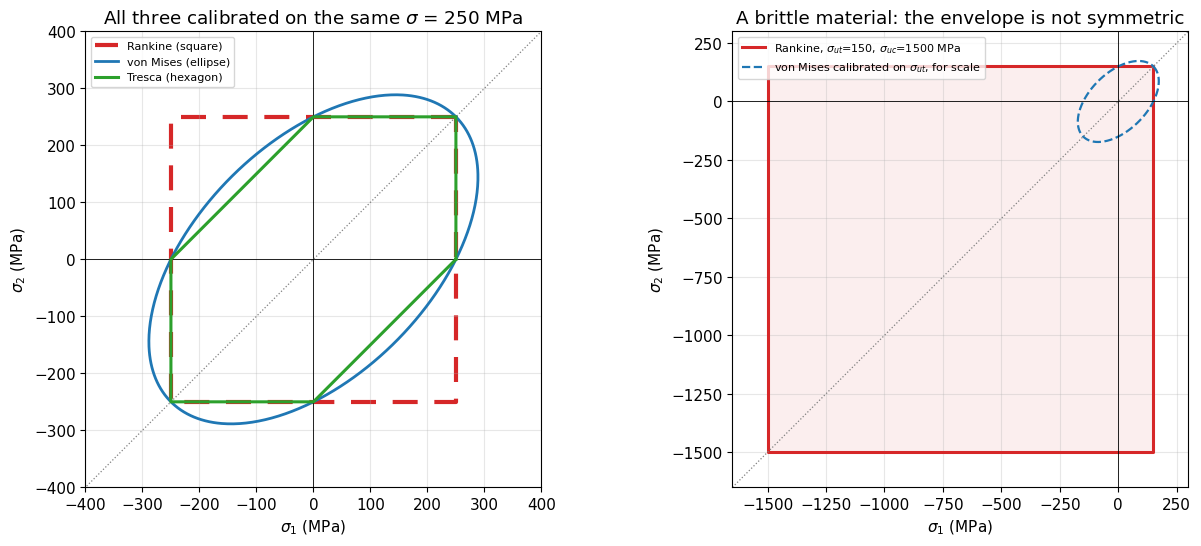

Left: Tresca shares four edges with the Rankine square (dashed underneath)
      and cuts the corners on the other two: that is the whole difference
      in plane stress, and the two criteria are NOT the same thing.
Left: the ductile criteria are CLOSED along the dotted hydrostatic line only
      because sigma_3 = 0 here. In full 3-D they are open prisms, infinite.
Right: the brittle envelope is bounded in tension and vast in compression.
       That asymmetry is why a single "strength" number is meaningless for
       a brittle material, and why it needs its own criterion.


In [7]:
# The three envelopes in plane stress (sigma_3 = 0), all calibrated on the SAME
# uniaxial tensile strength, so the comparison is fair.
S = 250.0
th = np.linspace(0, 2*np.pi, 600)

# von Mises: s1^2 - s1 s2 + s2^2 = S^2  -> parametrise the ellipse
a, b = np.sqrt(2)*S, np.sqrt(2.0/3)*S          # semi-axes along (1,1)/sqrt2 and (1,-1)/sqrt2
u, v = a*np.cos(th)/np.sqrt(2), b*np.sin(th)/np.sqrt(2)
vm1, vm2 = u + v, u - v

# Tresca: max(|s1|, |s2|, |s1-s2|) = S  -> the six vertices, in order
tr = np.array([[S, 0], [S, S], [0, S], [-S, 0], [-S, -S], [0, -S], [S, 0]], float)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

ax = axes[0]
# Draw order matters: the Tresca hexagon shares four edges with the Rankine square,
# so the square goes on first and DASHED, or it hides half the hexagon.
sq = np.array([[S, S], [-S, S], [-S, -S], [S, -S], [S, S]], float)
ax.plot(sq[:, 0], sq[:, 1], lw=3.0, ls=(0, (6, 4)), color='tab:red',
        label='Rankine (square)', zorder=1)
ax.plot(vm1, vm2, lw=2.0, color='tab:blue', label='von Mises (ellipse)', zorder=2)
ax.plot(tr[:, 0], tr[:, 1], lw=2.2, color='tab:green', label='Tresca (hexagon)', zorder=3)
ax.set_title(f'All three calibrated on the same $\\sigma$ = {S:.0f} MPa')

ax = axes[1]
sut, suc = 150.0, 1500.0                       # UO2, the values of the cell above
rect = np.array([[sut, sut], [-suc, sut], [-suc, -suc], [sut, -suc], [sut, sut]], float)
ax.plot(rect[:, 0], rect[:, 1], lw=2.2, color='tab:red',
        label=f'Rankine, $\\sigma_{{ut}}$={sut:.0f}, $\\sigma_{{uc}}$={suc:.0f} MPa')
ax.fill(rect[:, 0], rect[:, 1], color='tab:red', alpha=0.08)
ax.plot(vm1*sut/S, vm2*sut/S, lw=1.6, ls='--', color='tab:blue',
        label='von Mises calibrated on $\\sigma_{ut}$, for scale')
ax.set_title('A brittle material: the envelope is not symmetric')

for ax in axes:
    ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
    ax.plot([-1700, 1700], [-1700, 1700], ':', color='grey', lw=0.9)
    ax.set_xlabel(r'$\sigma_1$ (MPa)'); ax.set_ylabel(r'$\sigma_2$ (MPa)')
    ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='upper left')
axes[0].set_xlim(-400, 400); axes[0].set_ylim(-400, 400)
axes[1].set_xlim(-1650, 300); axes[1].set_ylim(-1650, 300)
plt.tight_layout(); plt.show()

print('Left: Tresca shares four edges with the Rankine square (dashed underneath)')
print('      and cuts the corners on the other two: that is the whole difference')
print('      in plane stress, and the two criteria are NOT the same thing.')
print('Left: the ductile criteria are CLOSED along the dotted hydrostatic line only')
print('      because sigma_3 = 0 here. In full 3-D they are open prisms, infinite.')
print('Right: the brittle envelope is bounded in tension and vast in compression.')
print('       That asymmetry is why a single "strength" number is meaningless for')
print('       a brittle material, and why it needs its own criterion.')
import os
# Export for the course notes: a no-op unless the author's environment variable is set.
_cn = os.environ.get("NDT_COURSE_NOTES_FIGURES", "")
if os.path.isdir(_cn):
    fig.savefig(os.path.join(_cn, "08_yield_loci.pdf"), bbox_inches="tight")


---
## 4. Exercises

**E1. The 15 %.** Prove that $\sigma_{Tr}/\sigma_{VM}$ attains its maximum $2/\sqrt3$
in pure shear and its minimum 1 whenever two principal stresses are equal.

**E2. Which criterion, and does it matter?** For the thin-shell pressure state of §2,
compute the margin under both criteria. How much design capacity does the code's choice
of Tresca cost you here? Would you argue for von Mises?

**E3. The criterion follows the mechanism.** A component carries $\sigma_1=\sigma_2=\sigma_3=+180$ MPa. Evaluate Tresca, von Mises and Rankine. Now say which verdict you would act on if the component were (a) an austenitic steel pipe, (b) a UO$_2$ pellet, and justify the choice by the *failure mechanism* rather than by the numbers.


**E4. What a safety factor measures.** A component carries principal stresses
$\sigma_1 = 0.35\,S_y$ and $\sigma_2 = -0.25\,S_y$, and the loads grow in proportion. A
tempting way to find the margin is to take the point of the Tresca hexagon *nearest* to
the load point, $(0.55, -0.45)\,S_y$, and divide the maximum shear there by the one at the
load point: $\tau'_{max}/\tau_{max} = 0.50/0.30$, a safety factor of 1.67.

(a) The cell below draws the hexagon, the load point and the load line through the
origin. Where does the load line actually meet the hexagon, and what is $N$?

(b) Is the nearest point on the load line? Why does the shear ratio still give 1.67?

(c) The table repeats the comparison for two more load points. Where do the two methods
disagree most, and why there? Which one is conservative, and why is "conservative" still
not a reason to use it?


  load point / S_y  N, load line    nearest point   |q|/|s|
     (0.35, -0.25)         1.667    (0.55, -0.45)     1.652
       (0.5, 0.45)         2.000     (1.00, 0.45)     1.630
       (0.2, -0.7)         1.111    (0.25, -0.75)     1.086


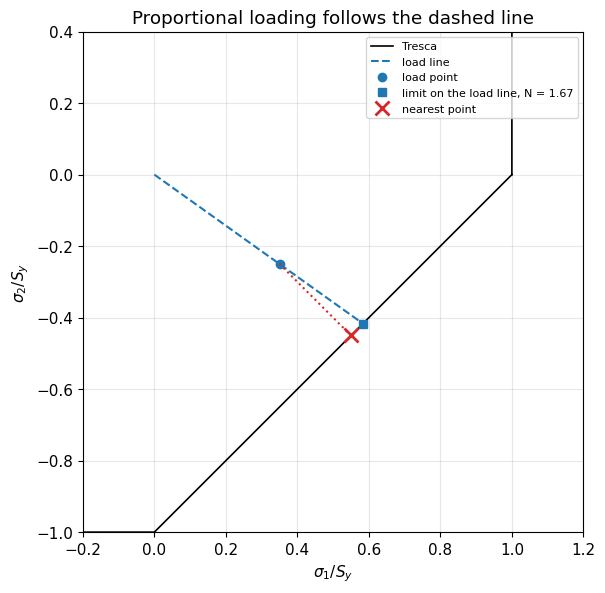

In [8]:
# E4 - a safety factor is measured along the load line, not to the nearest point.
def tresca_index(s1, s2):
    """Tresca comparison stress over S_y, plane stress (sigma_3 = 0)."""
    return max(abs(s1), abs(s2), abs(s1 - s2))

# The Tresca hexagon in (sigma_1, sigma_2)/S_y, sampled finely by direction.
th4 = np.linspace(0, 2 * np.pi, 20001)
d4 = np.c_[np.cos(th4), np.sin(th4)]
hexagon = d4 / np.array([tresca_index(*u) for u in d4])[:, None]

print(f"{'load point / S_y':>18} {'N, load line':>13} {'nearest point':>16} {'|q|/|s|':>9}")
cases = [(0.35, -0.25), (0.50, 0.45), (0.20, -0.70)]
for s1, s2 in cases:
    s = np.array([s1, s2])
    N = 1 / tresca_index(s1, s2)                   # scale the loads until yield
    q = hexagon[np.argmin(np.linalg.norm(hexagon - s, axis=1))]
    print(f"{str((s1, s2)):>18} {N:13.3f} {f'({q[0]:.2f}, {q[1]:.2f})':>16} "
          f"{np.linalg.norm(q) / np.linalg.norm(s):9.3f}")

# The first case, drawn.
s = np.array(cases[0]); N = 1 / tresca_index(*s); q = np.array([0.55, -0.45])
fig, ax = plt.subplots()
ax.plot(*hexagon.T, 'k', lw=1.2, label='Tresca')
ax.plot([0, N * s[0]], [0, N * s[1]], '--', color='tab:blue', label='load line')
ax.plot(*s, 'o', color='tab:blue', label='load point')
ax.plot(*(N * s), 's', color='tab:blue', label=f'limit on the load line, N = {N:.2f}')
ax.plot(*q, 'x', color='tab:red', ms=10, mew=2, label='nearest point')
ax.plot([s[0], q[0]], [s[1], q[1]], ':', color='tab:red')
ax.set_xlabel(r'$\sigma_1/S_y$'); ax.set_ylabel(r'$\sigma_2/S_y$')
ax.set_xlim(-0.2, 1.2); ax.set_ylim(-1.0, 0.4); ax.set_aspect('equal')
ax.set_title('Proportional loading follows the dashed line')
ax.legend(fontsize=8, loc='upper right'); plt.show()


*What the cell shows.* Proportional loading moves the stress state along the straight
line from the origin through the load point, so the safety factor is where that line
leaves the hexagon: $(0.583, -0.417)\,S_y$, $N = 1.667$. The nearest point $(0.55, -0.45)$
is the foot of the perpendicular from the load point, and it is not on the load line at
all. The shear ratio comes out right anyway because every point of the hexagon has the same
maximum shear, $S_y/2$, so $\tau'_{max}/\tau_{max} = 0.50/0.30$ is the load-line answer
whichever point of the hexagon was picked.

The table is where the two ideas separate. At $(0.35, -0.25)$ they differ by 1 %, which is
why the mistake goes unnoticed. At $(0.50, 0.45)$ both points lie on the same face,
$\sigma_1 = S_y$, but the load line reaches it at $(1.00, 0.90)$, slanting at 42° to the face
normal, while the nearest point $(1.00, 0.45)$ is straight across: $N = 2.00$ against 1.63.
The more the load line leans away from the normal, the further apart the two answers. The nearest point
always lies no further away than the point on the load line, so the nearest-point figure
is conservative, but it answers a different question, *what is the smallest change of
state that yields?*, and that is not the factor a design reports.


**E5. Why Beltrami fails for metals.** Starting from $\sigma_{\text{B}}$, show that it
predicts yielding in pure shear at $\tau = \sigma_Y/\sqrt{2(1+\nu)}$ and under hydrostatic
pressure at $p = \sigma_Y/\sqrt{3(1-2\nu)}$. Evaluate both for $\nu = 0.3$ and compare
them with Tresca and von Mises. Which of the two results rules the criterion out for
metals, and on what experimental evidence?
